# Phase 1: One-Class SVM for Novelty Detection in Manufacturing
**Objective:** Implement a One-Class Support Vector Machine (OC-SVM) to identify defective products using only "normal" baseline data during training.

## 1. Environment Setup & Library Imports
In this section, we initialize our workspace. We will rely on:
* **`scikit-learn`**: For datasets, model building (OC-SVM, Isolation Forest), and performance metrics.
* **`scikit-image`**: For extracting Histogram of Oriented Gradients (HOG) features from images.
* **`numpy` & `pandas`**: For data manipulation and matrix operations.
* **`matplotlib`**: For visualizing our data and Precision-Recall curves.


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, PrecisionRecallDisplay, precision_recall_curve, auc
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from skimage.feature import hog
import time
import joblib
import os


# This ensures matplotlib plots appear directly inside the notebook
%matplotlib inline

## 2. Data Acquisition & Preprocessing Pipeline
In traditional binary classification, models are trained on both healthy and defective examples. However, real-world manufacturing environments suffer from **extreme class imbalance** (e.g., 99.9% normal, 0.1% defective).

To simulate this using the MNIST dataset, we treat the digit **"1" as our "Normal" class** and all other digits as "Anomalies" (defects).
* **Training Set:** Consists strictly of normal data. The model learns the boundary of what constitutes a "healthy" state.
* **Testing Set:** Consists of unseen normal data mixed with a controlled percentage of anomalies (5%) to evaluate the model's precision and recall.

In [ ]:
# Define Data Pipeline
def load_and_preprocess_mnist():
    print("Fetching MNIST data via OpenML (this may take a minute on the first run)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data
    y = mnist.target

    print("Creating normal and anomaly splits...")
    # 1 for normal (inliers), -1 for anomalies (outliers)
    y_binary = np.where(y == '1', 1, -1)

    X_normal = X[y_binary == 1]
    X_anomaly = X[y_binary == -1]

    # Split: 80% train (pure normal), 20% test
    X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

    # Inject 5% anomalies into the test set
    anomaly_count = int(len(X_test_normal) * 0.05)
    X_test = np.vstack((X_test_normal, X_anomaly[:anomaly_count]))
    y_test = np.hstack((np.ones(len(X_test_normal)), -np.ones(anomaly_count)))

    # Shuffle test set
    shuffle_idx = np.random.permutation(len(X_test))
    X_test = X_test[shuffle_idx]
    y_test = y_test[shuffle_idx]

    return X_train_normal, X_test, y_test

## 3. Feature Extraction Modules
Raw pixel data often contains noise and redundant information, making it difficult for models to define clear decision boundaries. We implement two feature extraction techniques to compare against raw pixels:

1. **Principal Component Analysis (PCA):** A dimensionality reduction technique that compresses the data while retaining the majority of the variance (95%). This speeds up training and reduces the curse of dimensionality.
2. **Histogram of Oriented Gradients (HOG):** A computer vision technique that counts occurrences of gradient orientation. It is highly robust to lighting changes and is excellent for detecting physical shapes or surface defects (like scratches on manufactured parts).

In [ ]:
# Define Feature Extraction (PCA & HOG)
def extract_features_pca(X_train, X_test, variance_retained=0.95):
    print(f"Extracting PCA features (retaining {variance_retained*100}% variance)...")
    X_train_norm = X_train / 255.0
    X_test_norm = X_test / 255.0

    pca = PCA(n_components=variance_retained, random_state=42)
    X_train_pca = pca.fit_transform(X_train_norm)
    X_test_pca = pca.transform(X_test_norm)

    return X_train_pca, X_test_pca, pca

def extract_features_hog(X_data):
    print(f"Extracting HOG features for {len(X_data)} images...")
    hog_features = []
    # pixels per size affects model performance dramatically
    for i in range(len(X_data)):
        image = X_data[i].reshape((28, 28))
        fd = hog(image, orientations=8, pixels_per_cell=(4, 4),
                 cells_per_block=(1, 1), visualize=False)
        hog_features.append(fd)

    return np.array(hog_features)

## 4. Pipeline Execution (HOG Focus)
Here, we instantiate our data pipeline. Instead of relying on PCA, we will extract **HOG features for the entire dataset**.

Because HOG processes images patch-by-patch to calculate gradient vectors, running this on thousands of images is computationally intensive. *Note: This cell may take a few minutes to execute depending on your hardware.*

In [ ]:
# Execute the pipeline and extract HOG features
X_train_raw, X_test_raw, y_test = load_and_preprocess_mnist()

print(f"\nTraining set (Pure Normal): {X_train_raw.shape}")
print(f"Testing set (Mixed): {X_test_raw.shape}\n")

# Run HOG on the FULL datasets
# (This will take a little time as it processes thousands of images)
print("Starting HOG extraction for Training Set...")
X_train_hog = extract_features_hog(X_train_raw)

print("Starting HOG extraction for Testing Set...")
X_test_hog = extract_features_hog(X_test_raw)

print(f"\nHOG feature array shape (Train): {X_train_hog.shape}")
print(f"HOG feature array shape (Test): {X_test_hog.shape}")

Fetching MNIST data via OpenML (this may take a minute on the first run)...
Creating normal and anomaly splits...

Training set (Pure Normal): (6301, 784)
Testing set (Mixed): (1654, 784)

Starting HOG extraction for Training Set...
Extracting HOG features for 6301 images...
Starting HOG extraction for Testing Set...
Extracting HOG features for 1654 images...

HOG feature array shape (Train): (6301, 392)
HOG feature array shape (Test): (1654, 392)


## 5. Visual Sanity Check
Before feeding data into the OC-SVM, it is critical to confirm that our training set contains **no anomalies**. The following visualization samples the first five instances of our training data to ensure it consists entirely of our "Normal" class (the digit "1").

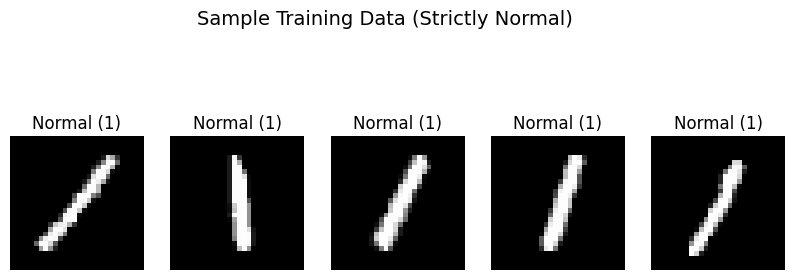

In [ ]:
# Let's visualize what the raw data looks like to confirm everything worked
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Reshape the flat 784 array back into a 28x28 image
    plt.imshow(X_train_raw[i].reshape(28, 28), cmap='gray')
    plt.title("Normal (1)")
    plt.axis('off')
plt.suptitle("Sample Training Data (Strictly Normal)", fontsize=14)
plt.show()